In [1]:
import torch
from bertviz import head_view, model_view
from transformers import AutoModel, AutoTokenizer

/Users/phuonglh/miniconda3/envs/LLM/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# 1. Load RoBERTa-base and enable output_attentions
model_name = "roberta-base"  # or your custom/fine-tuned model checkpoint
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
# 2. Prepare sample input text
text = "The dog didn't cross the street because it was too tired."
inputs = tokenizer(text, return_tensors="pt")

In [4]:
# Convert token IDs back to human-readable subword tokens
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

In [5]:
tokens

['<s>',
 'The',
 'Ġdog',
 'Ġdidn',
 "'t",
 'Ġcross',
 'Ġthe',
 'Ġstreet',
 'Ġbecause',
 'Ġit',
 'Ġwas',
 'Ġtoo',
 'Ġtired',
 '.',
 '</s>']

In [6]:
# 3. Model forward pass
with torch.no_grad():
    outputs = model(**inputs)

# outputs.attentions is a tuple of 12 tensors (one per layer)
# Each tensor has shape: (batch_size, num_heads, seq_len, seq_len)
attention = outputs.attentions

In [7]:
# 4. Render Interactive Head View
# Shows attention lines between tokens for specific layers/heads
head_view(attention, tokens)

<IPython.core.display.Javascript object>

In [8]:
# 5. Render Interactive Model View
# Shows a bird's-eye view across all 12 layers and 12 heads simultaneously
model_view(attention, tokens)

<IPython.core.display.Javascript object>

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
def plot_attention_head(attention, tokens, layer_idx=0, head_idx=0):
    """Plots a 2D heatmap of attention weights for a given layer and head."""
    # Extract attention matrix for the chosen layer and head
    # Shape: (seq_len, seq_len)
    attn_matrix = attention[layer_idx][0, head_idx].cpu().numpy()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        attn_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        cbar=True,
    )
    plt.title(f"RoBERTa Attention: Layer {layer_idx + 1}, Head {head_idx + 1}")
    plt.xlabel("Key Tokens (Attended To)")
    plt.ylabel("Query Tokens (Attending From)")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


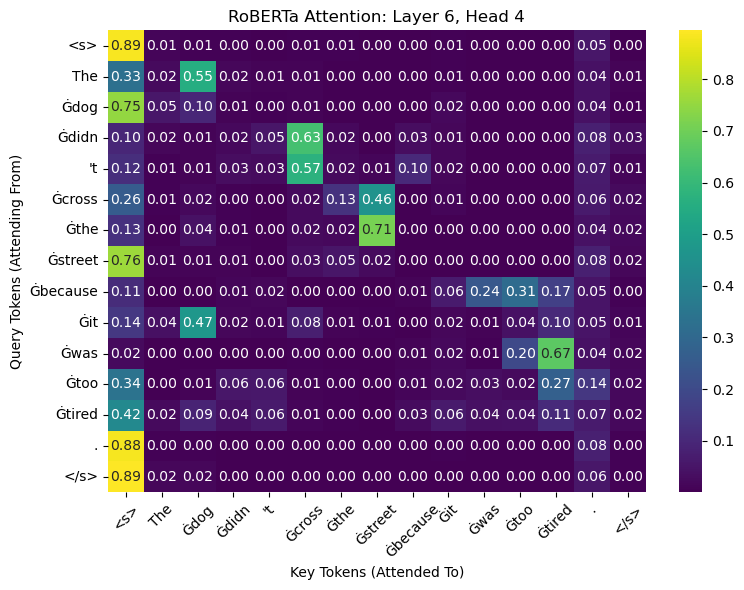

In [11]:
plot_attention_head(attention, tokens, layer_idx=5, head_idx=3)

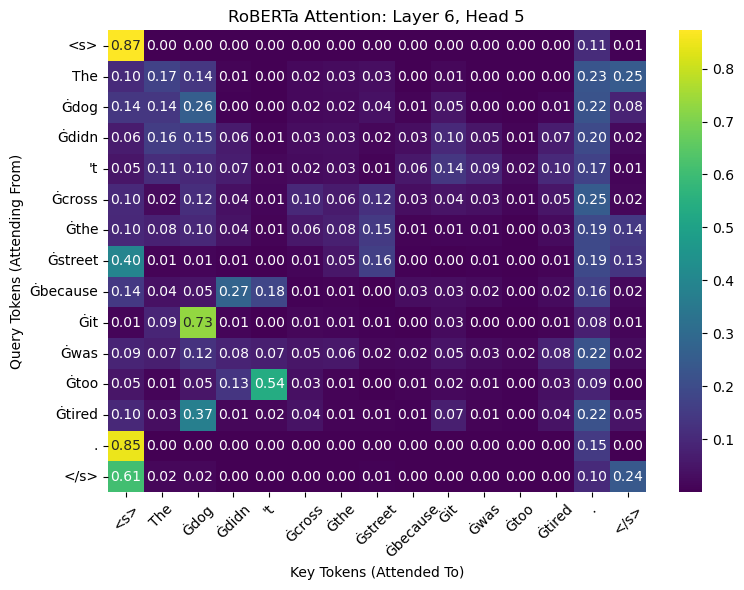

In [12]:
plot_attention_head(attention, tokens, layer_idx=5, head_idx=4)